# Defining and Identifying Precipitation Events

## Definitions
Total gauge precipitation
$$P(g) = \sum_{t=i}^{T}{P_g(t_i)}$$


Event precipitation defintion:
$$
\begin{aligned}
\mathcal{T}_{\text{start}} &= \{\, t_i \mid P(t_i) > P_{\text{th}},\; P(t_{i-1}) \le P_{\text{th}} \,\}, \\[6pt]
\mathcal{T}_{\text{end}}   &= \{\, t_j \mid t_j > t_i,\;
                                 P(t_j) \le P_{\text{th}} \text{ for } N \text{ consecutive time steps} \,\}, \\[8pt]
\mathcal{E} &= \{\, (t_i, t_j) \mid t_i \in \mathcal{T}_{\text{start}},\; t_j \in \mathcal{T}_{\text{end}},\; t_j > t_i \,\}, \\[8pt]
P_{\mathcal{E}_i} = P_{\text{event}}(t_i, t_j) &= \sum_{t = t_i}^{t_j} P(t), \quad \forall\, (t_i, t_j) \in \mathcal{E}, \\[6pt]
\text{where} \quad
&\mathcal{E} \text{ is the set containing of all events}, \\
&P(t) \text{ is the precipitation at time } t, \\
&P_{\text{th}} \text{ is the precipitation threshold defining a ``wet'' timestep, and} \\
&N \text{ is the number of consecutive ``dry'' timesteps (e.g., } N = 12\text{) that define an event end.}
\end{aligned}
$$




Event bias definition:
$$
\begin{aligned}
B_{\mathcal{E}_i}(g) &= P_{\mathcal{E}_i}(g) - P_{\mathcal{E}_i}(b), \\[6pt]
\text{where} \quad
&P_{\mathcal{E}_i}(g) = \sum_{t = t_{i,\text{start}}}^{t_{i,\text{end}}} P_g(t), \\[4pt]
&P_{\mathcal{E}_i}(b) = \sum_{t = t_{i,\text{start}}}^{t_{i,\text{end}}} P_b(t), \\[6pt]
&g \in \mathcal{G} \text{ is the set of test gauges}, \\
&b \text{ denotes the benchmark gauge}, \\
&\mathcal{E}_i = (t_{i,\text{start}}, t_{i,\text{end}}) \text{ is the } i\text{th event interval.}
\end{aligned}
$$


Positive biases
$$
\begin{aligned}
\mathcal{I}_{\text{pos}}(g) &= \{\, i \mid B_{\mathcal{E}_i}(g) > 0 \,\}, \\
\mathbf{B}_{\text{pos}}(g) &= 
\begin{bmatrix}
B_{(1)}(g) \\
B_{(2)}(g) \\
\vdots \\
B_{(n_{+})}(g)
\end{bmatrix},
\quad \text{where} \quad
B_{(1)}(g) \ge B_{(2)}(g) \ge \cdots \ge B_{(n_{+})}(g) > 0,
\end{aligned}
$$


Negative biases
$$
\begin{aligned}
\mathcal{I}_{\text{neg}}(g) &= \{\, i \mid B_{\mathcal{E}_i}(g) < 0 \,\}, \\
\mathbf{B}_{\text{neg}}(g) &= 
\begin{bmatrix}
B_{[1]}(g) \\
B_{[2]}(g) \\
\vdots \\
B_{[n_{-}]}(g)
\end{bmatrix},
\quad \text{where} \quad
B_{[1]}(g) \le B_{[2]}(g) \le \cdots \le B_{[n_{-}]}(g) < 0.
\end{aligned}$$


Absolute biases

$$\begin{aligned}
\mathcal{I}_{\text{abs}}(g) &= \{\, i \mid i \text{ indexes events}\,\}, \\
\mathbf{B}_{\text{abs}}(g) &= 
\begin{bmatrix}
|B|_{(1)}(g) \\
|B|_{(2)}(g) \\
\vdots \\
|B|_{(n)}(g)
\end{bmatrix},
\quad \text{where} \quad
|B|_{(1)}(g) \ge |B|_{(2)}(g) \ge \cdots \ge |B|_{(n)}(g) \ge 0,
\end{aligned}
$$

In [1]:
import os
os.chdir('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/')

# general
import glob
import datetime as dt

# data 
import xarray as xr 
import numpy as np
import pandas as pd
from utils.helper_funcs import calculate_wind_components

# plotting
import matplotlib.pyplot as plt


In [2]:
# Parameters
PRECIP_THRESHOLD = 0.05     # mm — to filter noise
DRY_GAP_STEPS = int(12 / 0.5) # number of 30-min intervals, 6-hours in this case

OUTPUT_DIR = '/storage/dlhogan/precipitation-rodeo/data/for_analysis/'

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

## Functions

In [ ]:
def get_relevant_dates(ds):
    
    """Get the relevant start and end dates for analysis based on data availability.
    Parameters:
        ds (xarray.Dataset): The dataset containing the data variables.
        analysis_type (str): Type of analysis ('all', 'warm', 'cold').
        water_year (int): The water year for seasonal analysis (e.g., 2023 for Oct 2022 - Sep 2023).
    """
    # for each datavar, get the time series of the first and last non-nan values
    starts = []
    ends = []
    for var in ds.data_vars:
        data = ds[var]
        first_valid_index = data.to_series().first_valid_index()
        last_valid_index = data.to_series().last_valid_index()
        starts.append(first_valid_index)
        ends.append(last_valid_index)
    latest_start = max(starts)
    if latest_start < pd.Timestamp("2021-10-01"):
        latest_start = pd.Timestamp("2021-10-01")
    earliest_end = min(ends)
    if earliest_end > pd.Timestamp("2023-06-12"):
        earliest_end = pd.Timestamp("2023-06-12")

    time_slice = slice(latest_start, earliest_end)  # instrument data range
    return time_slice

def drop_bad_or_irrelevant_vars(ds, nan_threshold=0.5):
    """Drop variables with known data quality issues or irrelevant to the analysis."""
    bad_vars = ['sail_pwd_rain', 'sail_squire_rain','sail_tbg_corr']  # example bad vars
    gridded_vars = ['ERA5-Land','PRISM']  # keep these regardless of nans
    for var in ds.data_vars:
        if var in ds.data_vars:
            if var in bad_vars:
                ds = ds.drop_vars(var)
            elif var in gridded_vars:
                continue  # keep gridded vars
            else:
                # calculate number of nans in variable
                nan_count = ds[var].isnull().sum().item()
                if (nan_count / ds.sizes['time']) > nan_threshold:  # if more than 50% nans, drop variable
                    ds = ds.drop_vars(var)
        else:
            continue
    return ds

def produce_df_from_ds(ds, precip_benchmark, precip_test):
    ds = ds[[precip_benchmark, precip_test]]
    # slice to relevant dates
    time_slice = get_relevant_dates(ds)
    ds = ds.sel(time=time_slice)
    # Convert to pandas for event grouping
    df = pd.DataFrame({
        precip_benchmark: ds[precip_benchmark].to_series(),
        precip_test: ds[precip_test].to_series(),
    })
    return df

def find_events_union(ds, precip_benchmark, precip_test, precip_thresh=0.0, max_gap_steps=1, resample_interval=None, limit=50, site='unknown', to_xarray=False, min_event_length=0):
    """
    Find precipitation events defined by the union of all columns in df:
      - an index belongs to an event if ANY column > precip_thresh
      - small dry gaps (<= max_gap_steps) between wet samples are filled/merged
    Returns a DataFrame with event_id, start_idx, end_idx, start_time (optional),
    end_time (optional), per-sensor sums, diff and abs_diff (benchmark minus others).
    """
    df = produce_df_from_ds(ds, precip_benchmark, precip_test)
    if resample_interval:
        df = df.resample(resample_interval).sum()
    else:
        resample_interval = '30min'
    
    if 'min' in resample_interval:
        resample_hours = int(resample_interval.replace('min','')) / 60
    elif 'h' in resample_interval:
        resample_hours = int(resample_interval.replace('h',''))
    elif 'd' in resample_interval:
        resample_hours = int(resample_interval.replace('d',''))
    else:
        print("Resample interval not recognized:", resample_interval)
        return
    
    # boolean wet series: True if any sensor reports > threshold at that time
    wet = (df > precip_thresh).any(axis=1).to_numpy(dtype=bool)
    true_idx = np.where(wet)[0] # indices of True values
    if len(true_idx) == 0:
        return pd.DataFrame()  # no events

    # fill/merge small dry gaps between True indices
    wet_filled = wet.copy()
    gaps = np.diff(true_idx) - 1  # number of dry steps between consecutive trues
    for i, gap in enumerate(gaps):
        if 0 < gap <= max_gap_steps: # if the gap is small enough, fill it
            start = true_idx[i] + 1 # fill it with the true index value
            end = true_idx[i + 1] # at the end, set to next true index
            wet_filled[start:end] = True # do this until this is no longer true

    # find start/end indices of contiguous True runs in wet_filled
    N = len(wet_filled)
    # starts where False -> True
    # locate where previous value is dry and the next is wet, then the next index is a new event
    starts = np.where((~wet_filled[:-1]) & (wet_filled[1:]))[0] + 1 if N > 1 else ( [0] if wet_filled[0] else [] )
    if wet_filled[0]:
        starts = np.concatenate(([0], starts)) if len(starts) > 0 else np.array([0])
    # ends where True -> False
    # locate where previous value is wet and the next is dry, then the current index is the end of an event
    ends = np.where((wet_filled[:-1]) & (~wet_filled[1:]))[0] if N > 1 else ( [0] if wet_filled[0] else [] )
    if wet_filled[-1]:
        ends = np.concatenate((ends, [N - 1])) if len(ends) > 0 else np.array([N - 1])

    starts = np.asarray(starts, dtype=int)
    ends = np.asarray(ends, dtype=int)

    # Build results
    rows = []
    # assume first column is benchmark (sensor A)
    benchmark = df.columns[0]
    for eid, (s, e) in enumerate(zip(starts, ends), start=1):
        block = df.iloc[s:e + 1]
        sums = block.sum()
        # compute difference relative to benchmark (benchmark - each instrument)
        # here we compute a single scalar diff as benchmark_total - mean(instrument totals)
        # but we'll also provide per-sensor totals so you can choose how to measure bias.
        benchmark_total = sums[benchmark]
        # choose a simple measure: benchmark minus mean of all others
        others = sums.drop(benchmark)
        if len(others) == 0:
            diff = 0.0
            max_diff = 0.0
        else:
            diff = others.mean() - benchmark_total
            max_diff = abs(block[benchmark] - block[df.columns[1]]).max()
        row = {
            "event_id": eid,
            "event_duration": (e - s) * resample_hours, # in hours
            "start_time": df.index[s] if isinstance(df.index, pd.DatetimeIndex) else None,
            "end_time": df.index[e] if isinstance(df.index, pd.DatetimeIndex) else None,
            "benchmark_total": float(benchmark_total),
            "others_total": float(others.mean()) if len(others) else np.nan,
            "diff": float(diff),
            "abs_diff": abs(float(diff)),
            "max_diff": max_diff,
        }
        # add each sensor total as separate keys
        # for col in df.columns:
        #     row[f"total_{col}"] = float(sums[col])
        rows.append(row)
    # create the DataFrame
    df_out = pd.DataFrame(rows)

    # drop rows with event_durations less than min_event_length
    df_out = df_out[df_out['event_duration'] > min_event_length]

    # make event_id the index
    df_out = df_out.set_index('event_id')

    # sort by abs_diff descending
    df_out = df_out.sort_values(by='abs_diff', ascending=False)

    # reset the index to reset the event_id numbering and add 1 to start from 1
    df_out = df_out.reset_index()
    df_out['event_id'] = df_out.index + 1
    df_out = df_out.set_index('event_id')
    
    # limit to top N events
    if limit:
        df_out = df_out.iloc[0:limit]

    if to_xarray:
        return events_to_xarray(df_out, test_gauge=precip_test, benchmark_gauge=precip_benchmark,
                                precip_threshold=precip_thresh,
                                dry_gap_hours=max_gap_steps * resample_hours,
                                site=site)
    else:
        return df_out # limit to top 50 events for brevity


def events_to_xarray(events_df, test_gauge, benchmark_gauge, precip_threshold, dry_gap_hours, site):
    events_ds = events_df.to_xarray()

    # add a dimension for the sensor
    events_ds = events_ds.expand_dims({'test_instrument': [test_gauge],
                                    'benchmark':[benchmark_gauge]})
    # create name for attribute assignment
    benchmark_name = benchmark_gauge.replace('_',' ').upper()
    test_gauge_name = test_gauge.replace('_',' ').upper()

    # add attrubutes
    variable_attributes_dict = {
        'event_duration': {'units': 'hrs',
                        'longname':'Duration of the event in hours'},
        'start_time': {'longname':'Start time of the event'},
        'end_time': {'longname':'End time of the event'},
        'benchmark_total': {'units':'mm',
                            'longname':f'Total precipitation from benchmark gauge ({benchmark_name}) over the event'},
        'others_total_mean': {'units':'mm',
                            'longname':f'Mean total precipitation from {test_gauge_name} over the event'},
        'diff': {'units':'mm',
                    'longname':f'Difference in total precipitation (benchmark minus {test_gauge_name}) over the event'},
        'abs_diff': {'units':'mm',
                        'longname':f'Absolute difference in total precipitation (benchmark minus {test_gauge_name}) over the event'},
        'max_diff': {'units':'mm',
                        'longname':f'Maximum difference in precipitation rate (benchmark minus {test_gauge_name}) over the event'},
    }

    global_attributes_dict = {
        'title': f'Precipitation Event Comparison between benchmarks and gauges',
        'site': site,
        'date_created': dt.datetime.now().isoformat(),
        'precip_threshold_mm': precip_threshold,
        'max_dry_gap_hours': dry_gap_hours,
        'description': f'This dataset contains precipitation event statistics comparing different benchmarks and gauges at the {site} site.',
    }

    dimension_atrribute_dict = {
        'event_id': {'longname':'Unique identifier for each precipitation event'},
        'test_instrument': {'longname':'Name of the test precipitation gauge/instrument'},
        'benchmark': {'longname':'Name of the benchmark precipitation gauge/instrument'},
    }

    for var in events_ds.data_vars:
        if var in variable_attributes_dict:
            events_ds[var].attrs.update(variable_attributes_dict[var])
    for dim in events_ds.dims:
        if dim in dimension_atrribute_dict:
            events_ds[dim].attrs.update(dimension_atrribute_dict[dim])
    events_ds.attrs.update(global_attributes_dict)
    return events_ds



In [4]:
def fast_mode_rounded(x):
    arr = x.to_numpy()
    arr = arr[~np.isnan(arr)]  # drop NaNs fast
    if arr.size == 0:
        return np.nan
    rounded = (10 * np.round(arr / 10)).astype(int)
    vals, counts = np.unique(rounded, return_counts=True)
    return vals[np.argmax(counts)]
def event_stats(met_var, time, start, end):
    """Compute event-averaged stats for each event window."""
    results = []
    for s, e in zip(start, end):
        sel = met_var.sel(time=slice(s, e))
        try: 
            results.append([
            sel.mean().item(),
            sel.max().item(),
            sel.min().item(),
            sel.std().item()
        ])
        except:
            results.append([np.nan, np.nan, np.nan, np.nan])
        
    return np.array(results)

In [5]:
def combine_events(event_dataset, met_dataset, vars_to_add):
    """Add meteorological statistics to each event in the event dataset."""
    benchmark_ds_list = []   

    for benchmark in event_dataset.benchmark.values:
        new_ds_list = []  # Reset inside benchmark loop

        for test_gauge in event_dataset.test_instrument.values:
            if test_gauge == benchmark:
                continue  # skip self comparisons

            ds = event_dataset.sel(benchmark=benchmark, test_instrument=test_gauge)

            for var in vars_to_add:
                if var != 'wdir_vec_mean':
                    stats = event_stats(
                        met_var=met_dataset[var],
                        time=met_dataset['time'],
                        start=ds['start_time'].values,
                        end=ds['end_time'].values
                    )
                    ds[f'{var}_mean'] = (('event_id'), stats[:,0])
                    ds[f'{var}_max'] = (('event_id'), stats[:,1])
                    ds[f'{var}_min'] = (('event_id'), stats[:,2])
                    ds[f'{var}_std'] = (('event_id'), stats[:,3])
                else:
                    if 'wdir_vec_mean' not in met_dataset:
                        continue
                    wdir_stats = []
                    for s, e in zip(ds['start_time'].values, ds['end_time'].values):
                        sel = met_dataset[var].sel(time=slice(s, e))
                        mode_val = fast_mode_rounded(sel.to_series())
                        wdir_stats.append(mode_val)
                    ds[f'{var}_mode'] = (('event_id'), wdir_stats)

            # Add this instrument dataset to the list for this benchmark
            new_ds_list.append(ds)

        # Concatenate across instruments for this benchmark
        combined_instrument_ds = xr.concat(new_ds_list, dim="test_instrument")
        benchmark_ds_list.append(combined_instrument_ds)

    # Concatenate across benchmarks
    combined_event_ds = xr.concat(benchmark_ds_list, dim="benchmark")
    return combined_event_ds

## Identify Gothic Events

In [6]:
site = 'gothic'
# precipitation datasets
gothic_prcp_ds = xr.open_dataset(f'/storage/dlhogan/precipitation-rodeo/data/processed/final/{site}_precipitation_30min.nc')
# drop all qc vars
qc_vars = [var for var in gothic_prcp_ds.data_vars if 'qc' in var.lower()]
gothic_prcp_ds = gothic_prcp_ds.drop_vars(qc_vars)
# gridded datasets
era5_land_prcp_ds = xr.open_dataset('/storage/dlhogan/precipitation-rodeo/data/processed/final/ERA5-Land/era5_land_gothic_1hr.nc')
prism_prcp_ds = xr.open_dataset('/storage/dlhogan/precipitation-rodeo/data/processed/final/PRISM/prism_site_data.nc').sel(site=site)
# meteorological datasets
gothic_met_ds = xr.open_dataset(f'/storage/dlhogan/precipitation-rodeo/data/processed/SAIL/met_30min.nc')
gothic_bb_ds = xr.open_dataset(f'/storage/dlhogan/precipitation-rodeo/data/processed/billy_barr/billy_barr_20211001-20230930_30min.nc')
# normalized meteorological datasets
gothic_met_norm_ds = xr.open_dataset(f'/storage/dlhogan/precipitation-rodeo/data/processed/final/gothicMet_met_normalized.nc')
gothic_bb_norm_ds = xr.open_dataset(f'/storage/dlhogan/precipitation-rodeo/data/processed/final/gothicBB_met_normalized.nc')

# drop bad or irrelevant vars
for ds in [gothic_prcp_ds, era5_land_prcp_ds, prism_prcp_ds, gothic_met_ds, gothic_bb_ds,
           gothic_met_norm_ds, gothic_bb_norm_ds]:
    ds = drop_bad_or_irrelevant_vars(ds)

# add wind components to gothic_bb_ds
u, v = calculate_wind_components(gothic_bb_ds['windSpeed'], gothic_bb_ds['windDirec'])
gothic_bb_ds = gothic_bb_ds.assign({'u_wind': (('time'), u),
                                     'v_wind': (('time'), v)})

# rename variables for consistency
rename_dict_sail = {
        'atmos_pressure': 'pressure',
        'temp_mean': 'temperature',
        'rh_mean': 'relative_humidity',
        'wspd_vec_mean': 'wind_speed',
        'u': 'u_wind',
        'v': 'v_wind',
    }
gothic_met_ds = gothic_met_ds.rename(rename_dict_sail)

rename_dict_bb = {'baromPress':'pressure',
                  'avAirTemp':'temperature',
                  'relHumidty':'relative_humidity',
                  'windSpeed':'wind_speed'
}
gothic_bb_ds = gothic_bb_ds.rename(rename_dict_bb)

### Precipitation Observations

In [7]:
events_ds_list = []
benchmarks = ['billy_barr_precip', 'sail_pluvio']
for benchmark in benchmarks:
    for test_gauge in list(gothic_prcp_ds.data_vars):
        if test_gauge == benchmark:
            print("Skipping same gauge:", test_gauge)
            pass
        events_ds_list.append(find_events_union(gothic_prcp_ds,
                                      precip_benchmark=benchmark,
                                      precip_test=test_gauge,
                                      precip_thresh=PRECIP_THRESHOLD, 
                                      max_gap_steps=DRY_GAP_STEPS, 
                                      min_event_length=2,
                                      resample_interval=None, 
                                      limit=None,
                                      site=site,
                                      to_xarray=True))
# Combine all event datasets into one
combinedGothicEvents_ds = xr.merge(events_ds_list)

Skipping same gauge: billy_barr_precip
Skipping same gauge: sail_pluvio


In [8]:
# Add meteorological variables to the dataset
VARS_TO_ADD = [
    'pressure',
    'temperature',
    'relative_humidity',
    'u_wind',
    'v_wind',
    'wind_speed',
    'wdir_vec_mean',
]

In [9]:
combinedGothicEventsWithMet_ds = combine_events(combinedGothicEvents_ds, gothic_met_ds, VARS_TO_ADD)
combinedGothicEventsWithMetBB_ds = combine_events(combinedGothicEvents_ds, gothic_bb_ds, VARS_TO_ADD)

In [10]:
combinedGothicEventsWithMetNormalized_ds = combine_events(combinedGothicEvents_ds, gothic_met_norm_ds, VARS_TO_ADD)
combinedGothicEventsWithMetBBNormalized_ds = combine_events(combinedGothicEvents_ds, gothic_bb_norm_ds, VARS_TO_ADD)

### Gridded Precipitation Data

In [11]:
mergedGridded_ds = xr.merge([gothic_prcp_ds['billy_barr_precip'].resample(time='1d').sum(), 
                             gothic_prcp_ds['sail_pluvio'].resample(time='1d').sum(), 
                             era5_land_prcp_ds['tp'].resample(time='1d').sum(), 
                             prism_prcp_ds['ppt'].resample(time='1d').sum()])
# rename ppt to prism_pprt and tp to era5_land_tp
mergedGridded_ds = mergedGridded_ds.rename({'ppt':'prism_ppt', 'tp':'era5_land_tp'})

# set minimum threshold to 0.1 mm for all values
mergedGridded_ds = mergedGridded_ds.where((mergedGridded_ds > 1) | np.isnan(mergedGridded_ds), 0)

In [12]:
events_ds_list = []
benchmarks = ['billy_barr_precip', 'sail_pluvio']
for benchmark in benchmarks:
    for test_gauge in list(mergedGridded_ds.data_vars):
        if test_gauge == benchmark:
            print("Skipping same gauge:", test_gauge)
            continue
        events_ds_list.append(find_events_union(mergedGridded_ds,
                                      precip_benchmark=benchmark,
                                      precip_test=test_gauge,
                                      precip_thresh=PRECIP_THRESHOLD, 
                                      max_gap_steps=0, 
                                      resample_interval='1d', 
                                      limit=50,
                                      site=site,
                                      to_xarray=True))
# Combine all event datasets into one
combinedGothicGriddedEvents_ds = xr.merge(events_ds_list)

Skipping same gauge: billy_barr_precip
Skipping same gauge: sail_pluvio


In [13]:
### add event specific meteorology
# SAIL Met
gothic_met_df = gothic_met_ds.to_dataframe()
gothic_met_df = gothic_met_df.resample('1D').agg({'temperature':'mean',
                                                 'relative_humidity':'mean',
                                                 'vapor_pressure_mean':'mean',
                                                 'pressure':'mean',
                                                 'u_wind':'mean',
                                                 'v_wind':'mean',
                                                 'wind_speed':'mean',
                                                 'wdir_vec_mean':fast_mode_rounded,})
gothic_met_ds_daily = gothic_met_df.to_xarray()

# Billy Barr Met
gothic_bb_df = gothic_bb_ds.to_dataframe()
gothic_bb_df = gothic_bb_df.resample('1D').agg({'temperature':'mean',
                                               'relative_humidity':'mean',
                                               'pressure':'mean',
                                               'u_wind':'mean',
                                               'v_wind':'mean',
                                               'wind_speed':'mean',})
gothic_bb_ds_daily = gothic_bb_df.to_xarray()

# Normalized SAIL Met
gothic_met_norm_df = gothic_met_norm_ds.to_dataframe()
gothic_met_norm_df = gothic_met_norm_df.resample('1D').agg({'temperature':'mean',
                                                 'relative_humidity':'mean',
                                                 'pressure':'mean',
                                                 'u_wind':'mean',
                                                 'v_wind':'mean',
                                                 'wind_speed':'mean',})
gothic_met_norm_ds_daily = gothic_met_norm_df.to_xarray()

# Normalized Billy Barr Met
gothic_bb_norm_df = gothic_bb_norm_ds.to_dataframe()
gothic_bb_norm_df = gothic_bb_norm_df.resample('1D').agg({'temperature':'mean',
                                               'relative_humidity':'mean',
                                               'pressure':'mean',
                                               'u_wind':'mean',
                                               'v_wind':'mean',
                                               'wind_speed':'mean',})
gothic_bb_norm_ds_daily = gothic_bb_norm_df.to_xarray()                                                 

In [14]:
# Add meteorological variables to the dataset
combinedGothicGriddedEventsWithMet_ds = combine_events(combinedGothicGriddedEvents_ds, gothic_met_ds_daily, VARS_TO_ADD)
combinedGothicGriddedEventsWithMetBB_ds = combine_events(combinedGothicGriddedEvents_ds, gothic_bb_ds_daily, VARS_TO_ADD)
# Add normalized meteorological variables
combinedGothicGriddedEventsWithMetNormalized_ds = combine_events(combinedGothicGriddedEvents_ds, gothic_met_norm_ds_daily, VARS_TO_ADD)
combinedGothicGriddedEventsWithMetBBNormalized_ds = combine_events(combinedGothicGriddedEvents_ds, gothic_bb_norm_ds_daily, VARS_TO_ADD)

### Save Files

In [15]:
save_files = True

if save_files:
    ### Save the datasets
    combinedGothicEvents_ds.to_netcdf(f'{OUTPUT_DIR}gothic_precipitation_event_comparisons.nc')
    combinedGothicGriddedEvents_ds.to_netcdf(f'{OUTPUT_DIR}gothic_gridded_precipitation_event_comparisons.nc')

    # SAIL Met
    combinedGothicEventsWithMet_ds.to_netcdf(f'{OUTPUT_DIR}gothic_precipitation_event_comparisons_sail_with_raw_met.nc')
    combinedGothicGriddedEventsWithMet_ds.to_netcdf(f'{OUTPUT_DIR}gothic_gridded_precipitation_event_comparisons_sail_with_raw_met.nc')

    # Billy Barr Met
    combinedGothicEventsWithMetBB_ds.to_netcdf(f'{OUTPUT_DIR}gothic_precipitation_event_comparisons_bb_with_raw_met.nc')
    combinedGothicGriddedEventsWithMetBB_ds.to_netcdf(f'{OUTPUT_DIR}gothic_gridded_precipitation_event_comparisons_bb_with_raw_met.nc')

    # Normalized meteorological datasets
    # SAIL met
    combinedGothicEventsWithMetNormalized_ds.to_netcdf(f'{OUTPUT_DIR}gothic_precipitation_event_comparisons_sail_with_normalized_met.nc')
    combinedGothicGriddedEventsWithMetNormalized_ds.to_netcdf(f'{OUTPUT_DIR}gothic_gridded_precipitation_event_comparisons_sail_with_normalized_met.nc')

    # Billy Barr met
    combinedGothicEventsWithMetBBNormalized_ds.to_netcdf(f'{OUTPUT_DIR}gothic_precipitation_event_comparisons_bb_with_normalized_met.nc')
    combinedGothicGriddedEventsWithMetBBNormalized_ds.to_netcdf(f'{OUTPUT_DIR}gothic_gridded_precipitation_event_comparisons_bb_with_normalized_met.nc')

## Identify Kettle Ponds Events

In [16]:
import xarray as xr
site = 'kettle_ponds'
kettle_ponds_prcp_ds = xr.open_dataset(f'/storage/dlhogan/precipitation-rodeo/data/processed/final/{site}_precipitation_30min.nc')

In [17]:
# drop all qc vars
qc_vars = [var for var in kettle_ponds_prcp_ds.data_vars if 'qc' in var.lower()] + ['precip_type']
kettle_ponds_prcp_ds = kettle_ponds_prcp_ds.drop_vars(qc_vars)
# gridded datasets
era5_land_prcp_ds = xr.open_dataset('/storage/dlhogan/precipitation-rodeo/data/processed/final/ERA5-Land/era5_land_gothic_1hr.nc')
prism_prcp_ds = xr.open_dataset('/storage/dlhogan/precipitation-rodeo/data/processed/final/PRISM/prism_site_data.nc').sel(site=site)
# meteorological datasets
kettle_ponds_asfs_met_ds = xr.open_dataset(f'/storage/dlhogan/precipitation-rodeo/data/processed/SPLASH/asfs30_30min.nc')
kettle_ponds_sos_met_ds = xr.open_dataset(f'/storage/dlhogan/precipitation-rodeo/data/processed/SOS/sos_ds_30min.nc')
# normalized meteorological datasets
kettle_ponds_asfs_met_norm_ds = xr.open_dataset(f'/storage/dlhogan/precipitation-rodeo/data/processed/final/kettlePondsAsfs30_met_normalized.nc')
kettle_ponds_sos_met_norm_ds = xr.open_dataset(f'/storage/dlhogan/precipitation-rodeo/data/processed/final/kettlePondsSOS_met_normalized.nc')

# drop bad or irrelevant vars
for ds in [kettle_ponds_prcp_ds, era5_land_prcp_ds, prism_prcp_ds, kettle_ponds_asfs_met_ds, kettle_ponds_sos_met_ds,
           kettle_ponds_asfs_met_norm_ds, kettle_ponds_sos_met_norm_ds]:
    ds = drop_bad_or_irrelevant_vars(ds)
# rename variables for consistency
rename_dict_sos = {'P_10m_c': 'pressure',
                   'T_3m_c': 'temperature',
                   'RH_3m_c': 'relative_humidity',
                   'spd_10m_c': 'wind_speed',
                   'dir_10m_c': 'wind_direction',
                   'u_10m_c': 'u_wind',
                   'v_10m_c': 'v_wind'}
kettle_ponds_sos_met_ds = kettle_ponds_sos_met_ds.rename(rename_dict_sos)

rename_dict_asfs = {'atmos_pressure': 'pressure',
                    'temp': 'temperature',
                    'rh': 'relative_humidity',
                    'wspd_u_mean': 'u_wind',
                    'wspd_v_mean': 'v_wind',
                    }
kettle_ponds_asfs_met_ds = kettle_ponds_asfs_met_ds.rename(rename_dict_asfs)

# calculate wind speed
kettle_ponds_asfs_met_ds['wind_speed'] = np.sqrt(kettle_ponds_asfs_met_ds['u_wind']**2 + kettle_ponds_asfs_met_ds['v_wind']**2)

### Precipitation Observations

In [18]:
events_ds_list = []
benchmarks = ['billy_barr_precip', 'splash_pluvio']
for benchmark in benchmarks:
    for test_gauge in list(kettle_ponds_prcp_ds.data_vars):
        if test_gauge == benchmark:
            print("Skipping same gauge:", test_gauge)
            pass
        print(test_gauge, benchmark)
        events_ds_list.append(find_events_union(kettle_ponds_prcp_ds,
                                      precip_benchmark=benchmark,
                                      precip_test=test_gauge,
                                      precip_thresh=PRECIP_THRESHOLD, 
                                      max_gap_steps=DRY_GAP_STEPS, 
                                      min_event_length=2,
                                      resample_interval=None, 
                                      limit=50,
                                      site=site,
                                      to_xarray=True))
# Combine all event datasets into one
combinedKettlePondsEvents_ds = xr.merge(events_ds_list)

Skipping same gauge: billy_barr_precip
billy_barr_precip billy_barr_precip
splash_pluvio billy_barr_precip
splash_ld_unadjusted billy_barr_precip
splash_ld_holyroyd billy_barr_precip
splash_ld_brandes billy_barr_precip
splash_ld_heymsfield billy_barr_precip
sos_SWE_p1 billy_barr_precip
sos_SWE_p2 billy_barr_precip
sos_SWE_p3 billy_barr_precip
sos_SWE_p4 billy_barr_precip
sail_squire_m2009_1 billy_barr_precip
sail_squire_m2009_2 billy_barr_precip
sail_squire_ws88diw billy_barr_precip
sail_squire_ws2012 billy_barr_precip
billy_barr_precip splash_pluvio
Skipping same gauge: splash_pluvio
splash_pluvio splash_pluvio
splash_ld_unadjusted splash_pluvio
splash_ld_holyroyd splash_pluvio
splash_ld_brandes splash_pluvio
splash_ld_heymsfield splash_pluvio
sos_SWE_p1 splash_pluvio
sos_SWE_p2 splash_pluvio
sos_SWE_p3 splash_pluvio
sos_SWE_p4 splash_pluvio
sail_squire_m2009_1 splash_pluvio
sail_squire_m2009_2 splash_pluvio
sail_squire_ws88diw splash_pluvio
sail_squire_ws2012 splash_pluvio


In [19]:
combinedKettlePondsEventsWithMetASFS_ds = combine_events(combinedKettlePondsEvents_ds, kettle_ponds_asfs_met_ds, VARS_TO_ADD)
combinedKettlePondsEventsWithMetSOS_ds = combine_events(combinedKettlePondsEvents_ds, kettle_ponds_sos_met_ds, VARS_TO_ADD)
combinedKettlePondsEventsWithMetNormalizedASFS_ds = combine_events(combinedKettlePondsEvents_ds, kettle_ponds_asfs_met_norm_ds, VARS_TO_ADD)
combinedKettlePondsEventsWithMetBBNormalizedSOS_ds = combine_events(combinedKettlePondsEvents_ds, kettle_ponds_sos_met_norm_ds, VARS_TO_ADD)

### Gridded Precipitation Data

In [20]:
mergedGridded_ds = xr.merge([kettle_ponds_prcp_ds['billy_barr_precip'].resample(time='1d').sum(), 
                             kettle_ponds_prcp_ds['splash_pluvio'].resample(time='1d').sum(), 
                             era5_land_prcp_ds['tp'].resample(time='1d').sum(), 
                             prism_prcp_ds['ppt'].resample(time='1d').sum()])
# rename ppt to prism_pprt and tp to era5_land_tp
mergedGridded_ds = mergedGridded_ds.rename({'ppt':'prism_ppt', 'tp':'era5_land_tp'})

# set minimum threshold to 0.1 mm for all values
mergedGridded_ds = mergedGridded_ds.where((mergedGridded_ds > 1) | np.isnan(mergedGridded_ds), 0)

In [21]:
events_ds_list = []
benchmarks = ['billy_barr_precip', 'splash_pluvio']
for benchmark in benchmarks:
    for test_gauge in list(mergedGridded_ds.data_vars):
        if test_gauge == benchmark:
            print("Skipping same gauge:", test_gauge)
            continue
        events_ds_list.append(find_events_union(mergedGridded_ds,
                                      precip_benchmark=benchmark,
                                      precip_test=test_gauge,
                                      precip_thresh=PRECIP_THRESHOLD, 
                                      max_gap_steps=0, 
                                      resample_interval='1d', 
                                      limit=50,
                                      site=site,
                                      to_xarray=True))
# Combine all event datasets into one
combinedKettlePondsGriddedEvents_ds = xr.merge(events_ds_list)

Skipping same gauge: billy_barr_precip
Skipping same gauge: splash_pluvio


In [22]:
### add event specific meteorology
# SOS Met
kettle_ponds_sos_met_df = kettle_ponds_sos_met_ds.to_dataframe()
kettle_ponds_sos_met_df = kettle_ponds_sos_met_df.resample('1D').agg({'temperature':'mean',
                                                 'relative_humidity':'mean',
                                                 'pressure':'mean',
                                                 'u_wind':'mean',
                                                 'v_wind':'mean',
                                                 'wind_speed':'mean'})
kettle_ponds_sos_met_ds_daily = kettle_ponds_sos_met_df.to_xarray()

# ASFS Met
kettle_ponds_asfs_met_df = kettle_ponds_asfs_met_ds.to_dataframe()
kettle_ponds_asfs_met_df = kettle_ponds_asfs_met_df.resample('1D').agg({'temperature':'mean',
                                               'relative_humidity':'mean',
                                               'pressure':'mean',
                                               'u_wind':'mean',
                                               'v_wind':'mean',
                                               'wind_speed':'mean',})
kettle_ponds_asfs_met_ds_daily = kettle_ponds_asfs_met_df.to_xarray()

# Normalized SOS Met
kettle_ponds_sos_met_norm_df = kettle_ponds_sos_met_norm_ds.to_dataframe()
kettle_ponds_sos_met_norm_df = kettle_ponds_sos_met_norm_df.resample('1D').agg({'temperature':'mean',
                                                 'relative_humidity':'mean',
                                                 'pressure':'mean',
                                                 'u_wind':'mean',
                                                 'v_wind':'mean',
                                                 'wind_speed':'mean',})
kettle_ponds_sos_met_norm_ds_daily = kettle_ponds_sos_met_norm_df.to_xarray()

# Normalized ASFS Met
kettle_ponds_asfs_met_norm_df = kettle_ponds_asfs_met_norm_ds.to_dataframe()
kettle_ponds_asfs_met_norm_df = kettle_ponds_asfs_met_norm_df.resample('1D').agg({'temperature':'mean',
                                               'relative_humidity':'mean',
                                               'pressure':'mean',
                                               'u_wind':'mean',
                                               'v_wind':'mean',
                                               'wind_speed':'mean',})
kettle_ponds_asfs_met_norm_ds_daily = kettle_ponds_asfs_met_norm_df.to_xarray()

In [23]:
combinedKettlePondsGriddedEventsWithMetASFS_ds = combine_events(combinedKettlePondsGriddedEvents_ds, kettle_ponds_asfs_met_ds_daily, VARS_TO_ADD)
combinedKettlePondsGriddedEventsWithMetSOS_ds = combine_events(combinedKettlePondsGriddedEvents_ds, kettle_ponds_sos_met_ds_daily, VARS_TO_ADD)
# Add normalized meteorological variables
combinedKettlePondsGriddedEventsWithMetNormalizedASFS_ds = combine_events(combinedKettlePondsGriddedEvents_ds, kettle_ponds_asfs_met_norm_ds_daily, VARS_TO_ADD)
combinedKettlePondsGriddedEventsWithMetBBNormalizedSOS_ds = combine_events(combinedKettlePondsGriddedEvents_ds, kettle_ponds_sos_met_norm_ds_daily, VARS_TO_ADD)

In [24]:
save_files = True
if save_files:
    # Save the datasets
    combinedKettlePondsEvents_ds.to_netcdf(f'{OUTPUT_DIR}/kettle_ponds_precipitation_event_comparisons.nc')
    combinedKettlePondsGriddedEvents_ds.to_netcdf(f'{OUTPUT_DIR}/kettle_ponds_gridded_precipitation_event_comparisons.nc')
    # ASFS datasets
    combinedKettlePondsEventsWithMetASFS_ds.to_netcdf(f'{OUTPUT_DIR}/kettle_ponds_precipitation_event_comparisons_asfs_with_raw_met.nc')
    combinedKettlePondsGriddedEventsWithMetASFS_ds.to_netcdf(f'{OUTPUT_DIR}/kettle_ponds_gridded_precipitation_event_comparisons_asfs_with_raw_met.nc')

    # SOS datasets
    combinedKettlePondsEventsWithMetSOS_ds.to_netcdf(f'{OUTPUT_DIR}/kettle_ponds_precipitation_event_comparisons_sos_with_raw_met.nc')
    combinedKettlePondsGriddedEventsWithMetSOS_ds.to_netcdf(f'{OUTPUT_DIR}/kettle_ponds_gridded_precipitation_event_comparisons_sos_with_raw_met.nc')

    # Normalized meteorological datasets
    # ASFS datasets
    combinedKettlePondsEventsWithMetNormalizedASFS_ds.to_netcdf(f'{OUTPUT_DIR}/kettle_ponds_precipitation_event_comparisons_asfs_with_normalized_met.nc')
    combinedKettlePondsGriddedEventsWithMetNormalizedASFS_ds.to_netcdf(f'{OUTPUT_DIR}/kettle_ponds_gridded_precipitation_event_comparisons_asfs_with_normalized_met.nc')

    # SOS datasets
    combinedKettlePondsEventsWithMetBBNormalizedSOS_ds.to_netcdf(f'{OUTPUT_DIR}/kettle_ponds_precipitation_event_comparisons_sos_with_normalized_met.nc')
    combinedKettlePondsGriddedEventsWithMetBBNormalizedSOS_ds.to_netcdf(f'{OUTPUT_DIR}/kettle_ponds_gridded_precipitation_event_comparisons_sos_with_normalized_met.nc')

## Calculate Event Contributions

In [25]:
def compute_event_contributions(event_ds: xr.Dataset, benchmark_name: str, bias='absolute'):
    """
    Compute each event's contribution (in %) to total bias and total precipitation
    for all instruments compared against a given benchmark.

    Parameters
    ----------
    event_ds : xarray.Dataset
        Dataset containing 'abs_diff', 'benchmark_total', 'test_instrument', and 'event_id' variables.
    benchmark_name : str
        Name of the benchmark instrument to compare against.
    bias : str, optional
        Type of bias to compute contributions for. Options are 'absolute', 'postive' or 'negative.

    Returns
    -------
    bias_df : pandas.DataFrame
        Each row is an event_id; each column is an instrument.
        Values are the percentage contribution of that event to total bias.
    ppt_df : pandas.DataFrame
        Each row is an event_id; each column is an instrument.
        Values are the percentage contribution of that event to total total precipitation.
    """
    if bias not in ['absolute', 'positive', 'negative']:
        raise ValueError("bias parameter must be one of 'absolute', 'positive', or 'negative'.")
    bias_contribution = {}
    total_ppt_contribution = {}

    # Select events for the specified benchmark
    benchmark_events = event_ds.sel(benchmark=benchmark_name)

    # Iterate over instruments
    for ins in benchmark_events.test_instrument.values:
        if ins == benchmark_name:
            continue  # skip self comparisons

        tmp = benchmark_events.sel(test_instrument=ins).to_dataframe()
        total_ppt = benchmark_events.sel(test_instrument=ins).to_dataframe()['others_total'].sum().item()
        # Totals for normalization
        if bias == 'absolute':
            total_bias = tmp['abs_diff'].sum().item()
        elif bias == 'positive':
            tmp = tmp.where(tmp['diff'] > 0).sort_values(by='diff', ascending=False)
            total_bias = tmp['diff'].sum().item()
        elif bias == 'negative':
            # rank by negative diff 
            tmp = tmp.where(tmp['diff'] < 0).sort_values(by='diff')
            total_bias = tmp['diff'].sum().item()
        
        ins_bias_contribution = []
        ins_total_ppt_contribution = []

        # iterate over events
        for eid in tmp.index:
            try:
                event = tmp.loc[eid]
            except KeyError:
                # instrument may not have this event
                ins_bias_contribution.append(0.0)
                ins_total_ppt_contribution.append(0.0)
                continue
            
            if bias == 'absolute':
                event_diff = event['abs_diff'].item()
            elif bias == 'positive':
                event_diff = event['diff'].item() if event['diff'].item() > 0 else 0.0
            elif bias == 'negative':
                event_diff = event['diff'].item() if event['diff'].item() < 0 else 0.0
            ppt = event['others_total'].item()

            # compute relative contributions
            bias_contrib = (event_diff / total_bias * 100) if abs(total_bias) > 0 else 0.0
            ppt_contrib = (ppt / total_ppt * 100) if total_ppt > 0 else 0.0

            ins_bias_contribution.append(bias_contrib)
            ins_total_ppt_contribution.append(ppt_contrib)

        # store per-instrument results
        bias_contribution[ins] = ins_bias_contribution
        total_ppt_contribution[ins] = ins_total_ppt_contribution


    # event_ids = benchmark_events['event_id'].values
    bias_df = pd.DataFrame(bias_contribution,)
    ppt_df = pd.DataFrame(total_ppt_contribution,)

    return bias_df, ppt_df


In [26]:
# Select events for the specified benchmark
benchmark_events = combinedGothicEvents_ds.sel(benchmark='billy_barr_precip')
bias_contribution = {}
total_ppt_contribution = {}
# Iterate over instruments
for ins in benchmark_events.test_instrument.values:
    if ins == 'billy_barr_precip':
        continue  # skip self comparisons

    tmp = benchmark_events.sel(test_instrument=ins).to_dataframe()
    total_ppt = tmp['others_total'].sum().item()
    # Totals for normalization
    total_bias = tmp['abs_diff'].sum().item()
    
    ins_bias_contribution = []
    ins_total_ppt_contribution = []

    # iterate over events
    for eid in tmp.index:
        try:
            event = tmp.loc[eid]
        except KeyError:
            # instrument may not have this event
            ins_bias_contribution.append(0.0)
            ins_total_ppt_contribution.append(0.0)
            continue
        
        
        event_diff = event['abs_diff'].item()
        ppt = event['others_total'].item()

        # compute relative contributions
        bias_contrib = (event_diff / total_bias * 100) if abs(total_bias) > 0 else 0.0
        ppt_contrib = (ppt / total_ppt * 100) if total_ppt > 0 else 0.0

        ins_bias_contribution.append(bias_contrib)
        ins_total_ppt_contribution.append(ppt_contrib)

    # store per-instrument results
    bias_contribution[ins] = ins_bias_contribution
    total_ppt_contribution[ins] = ins_total_ppt_contribution
    

<Axes: >

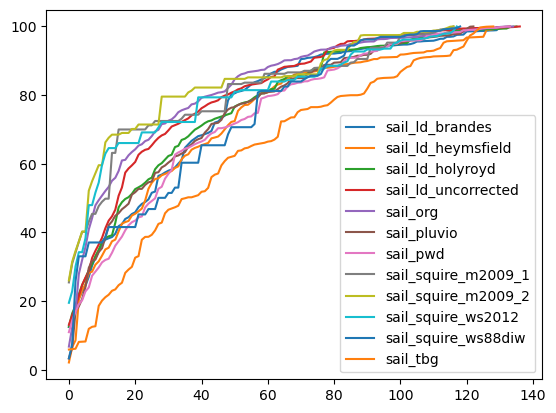

In [27]:
pd.DataFrame(total_ppt_contribution).cumsum().plot()

In [28]:
def plot_cumulative_contributions(bias_df: pd.DataFrame, ppt_df: pd.DataFrame, benchmark_name: str, site: str, output_dir: str, limit=None, top_n=None, save=False):
    """
    Plot cumulative contributions to total bias and total precipitation for each instrument.

    Parameters
    ----------
    bias_df : pandas.DataFrame
        DataFrame with event_id as index and instruments as columns.
        Values are percentage contributions to total bias.
    ppt_df : pandas.DataFrame
        DataFrame with event_id as index and instruments as columns.
        Values are percentage contributions to total precipitation.
    benchmark_name : str
        Name of the benchmark instrument.
    site : str
        Site name for plot titles and filenames.
    output_dir : str
        Directory to save the plots.
    """
    import matplotlib.pyplot as plt
    plt.style.use('seaborn-v0_8-talk')

    # Cumulative sum over events
    bias_cumsum = bias_df.cumsum()
    ppt_cumsum = ppt_df.cumsum()

    # Plot settings
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    for ins in bias_cumsum.columns:
        if ins == 'sail_pwd_rain' or ins == 'sail_tbg_corr' or ins == 'sail_squire_rain':
            continue  # skip this instrument
        axs[0].plot(bias_cumsum.index, bias_cumsum[ins], label=ins)
    if top_n:
        axs[0].axvline(x=top_n, color='r', linestyle='--', lw=4)
    axs[0].set_title(f'Cumulative Contribution to Total Bias\nBenchmark: {benchmark_name} at {site}')
    axs[0].set_xlabel('Event Rank')
    axs[0].set_ylabel('Cumulative Contribution to Total Bias (%)')
    axs[0].grid()

    for ins in ppt_cumsum.columns:
        if ins == 'sail_pwd_rain' or ins == 'sail_tbg_corr' or ins == 'sail_squire_rain':
            continue  # skip this instrument
        ppt_cumsum[ins].plot(ax=axs[1], label=ins)
    if top_n:
        axs[1].axvline(x=top_n, color='r', linestyle='--', lw=4)
    axs[1].set_title(f'Cumulative Contribution to Total Precipitation\nBenchmark: {benchmark_name} at {site}')
    axs[1].set_xlabel('Event Rank')
    axs[1].set_ylabel('Cumulative Contribution to Total Precipitation (%)')
    axs[1].grid()

    for ax in axs:
        if limit:
            ax.set_xlim(1, limit)
        ax.set_ylim(-5, 105)

    # add legend centerd below plots
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.13), fontsize='large')
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    if save:
        fig.savefig(os.path.join(output_dir, f'{site}_{benchmark_name}_cumulative_contributions.png'))

### Gothic 

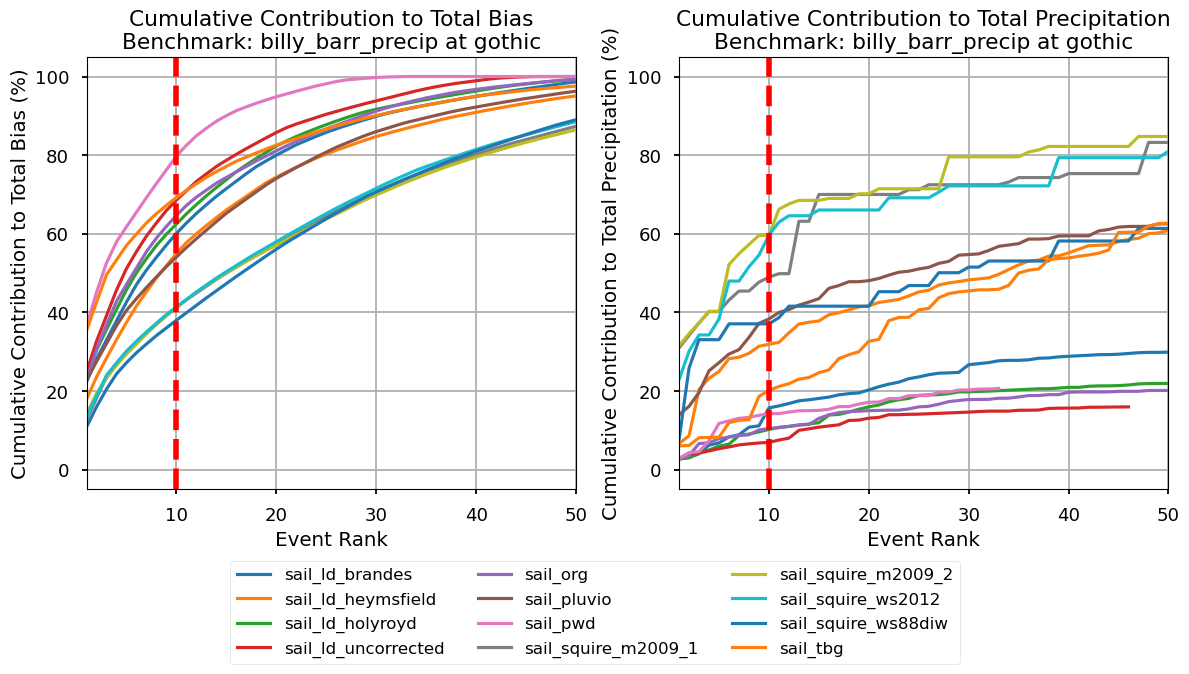

In [29]:
gothic_bias_df, gothic_total_ppt_df = compute_event_contributions(combinedGothicEvents_ds, benchmark_name='billy_barr_precip', bias='negative')

# for each, get the sum of the top 10 contributors
top_n = 10
bias_contribution_sums = gothic_bias_df.apply(lambda col: col.nlargest(top_n).sum())
total_ppt_contribution_sums = gothic_total_ppt_df.iloc[0:10].sum(axis=0)

plot_cumulative_contributions(gothic_bias_df, gothic_total_ppt_df, benchmark_name='billy_barr_precip', site='gothic', output_dir=OUTPUT_DIR, limit=50, top_n=top_n, save=False)

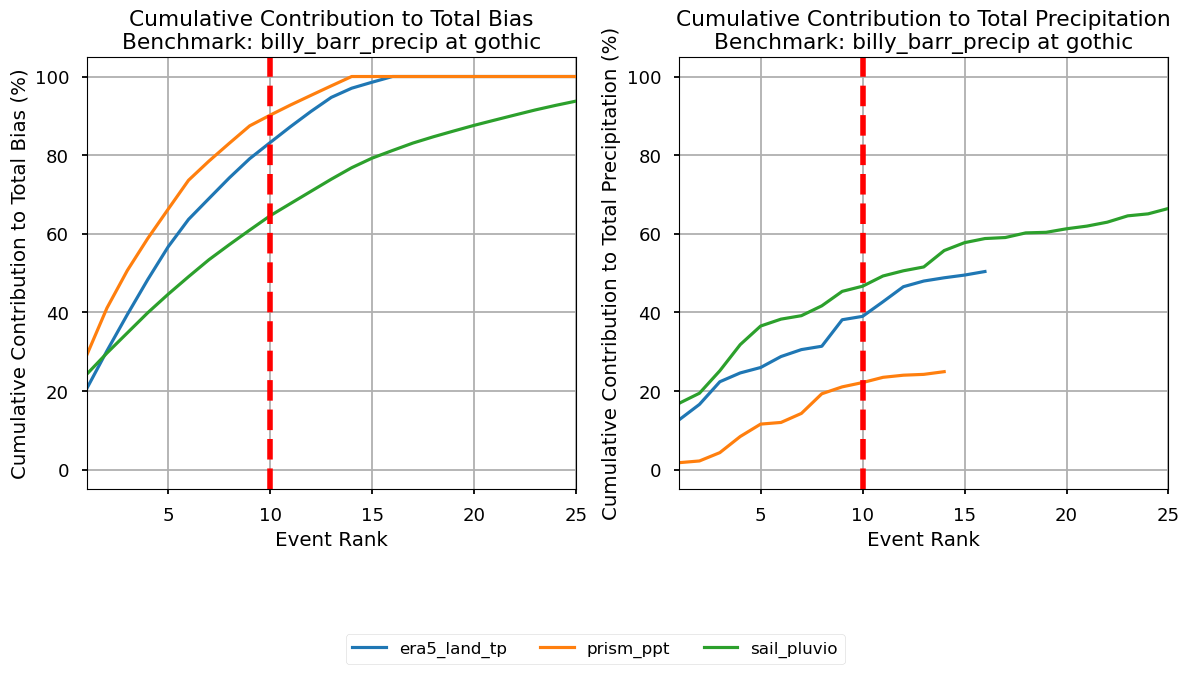

In [30]:
gothic_bias_df, gothic_total_ppt_df = compute_event_contributions(combinedGothicGriddedEvents_ds, benchmark_name='billy_barr_precip', bias='negative')

# for each, get the sum of the top 10 contributors
top_n = 10
bias_contribution_sums = gothic_bias_df.apply(lambda col: col.nlargest(top_n).sum())
total_ppt_contribution_sums = gothic_total_ppt_df.iloc[0:10].sum(axis=0)

plot_cumulative_contributions(gothic_bias_df, gothic_total_ppt_df, benchmark_name='billy_barr_precip', site='gothic', output_dir=OUTPUT_DIR, limit=25, top_n=top_n, save=False)

#### Absolute bias contributions

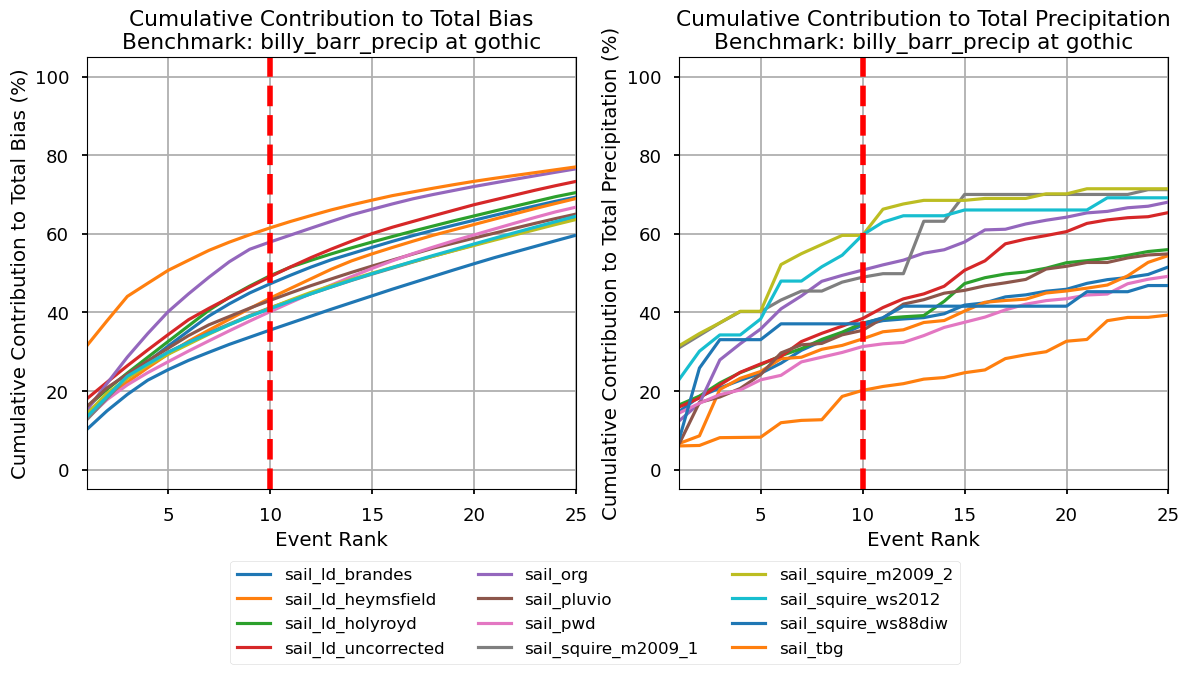

In [31]:
gothic_bias_df, gothic_total_ppt_df = compute_event_contributions(combinedGothicEvents_ds, benchmark_name='billy_barr_precip', bias='absolute')

# for each, get the sum of the top 10 contributors
top_n = 10
bias_contribution_sums = gothic_bias_df.apply(lambda col: col.nlargest(top_n).sum())
total_ppt_contribution_sums = gothic_total_ppt_df.iloc[0:10].sum(axis=0)

plot_cumulative_contributions(gothic_bias_df, gothic_total_ppt_df, benchmark_name='billy_barr_precip', site='gothic', output_dir=OUTPUT_DIR, limit=25, top_n=top_n, save=False)

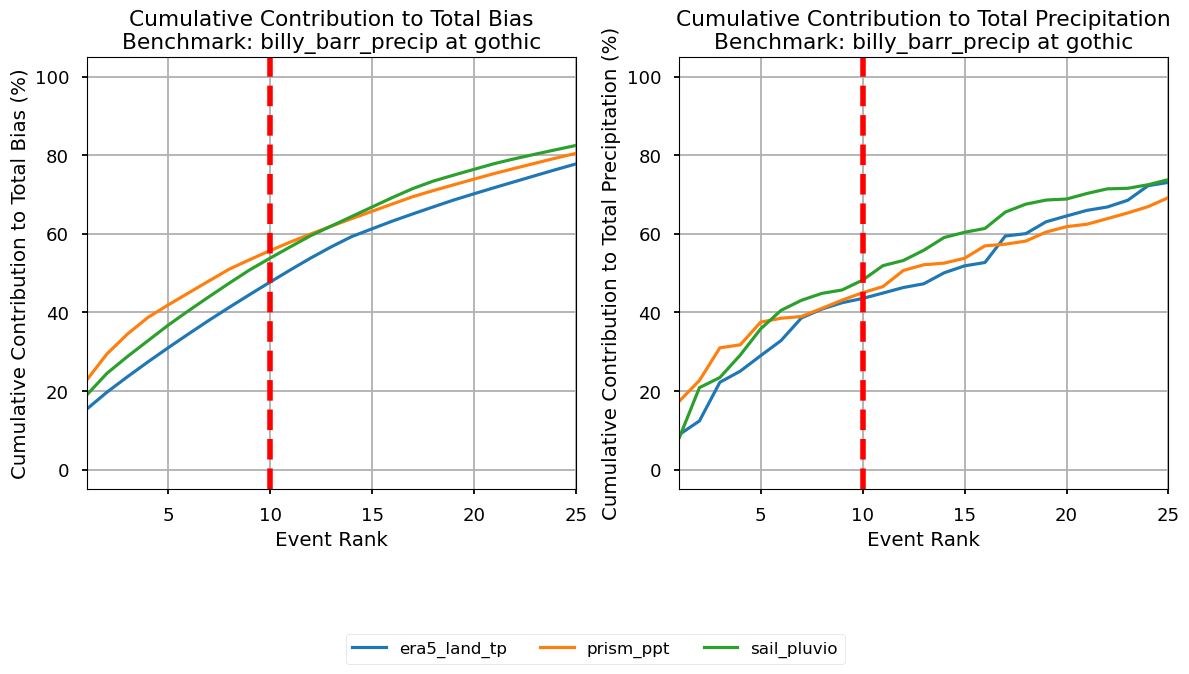

In [32]:
gothic_bias_df, gothic_total_ppt_df = compute_event_contributions(combinedGothicGriddedEvents_ds, benchmark_name='billy_barr_precip', bias='absolute')

# for each, get the sum of the top 10 contributors
top_n = 10
bias_contribution_sums = gothic_bias_df.apply(lambda col: col.nlargest(top_n).sum())
total_ppt_contribution_sums = gothic_total_ppt_df.iloc[0:10].sum(axis=0)

plot_cumulative_contributions(gothic_bias_df, gothic_total_ppt_df, benchmark_name='billy_barr_precip', site='gothic', output_dir=OUTPUT_DIR, limit=25, top_n=top_n, save=False)

#### Positive bias contributions

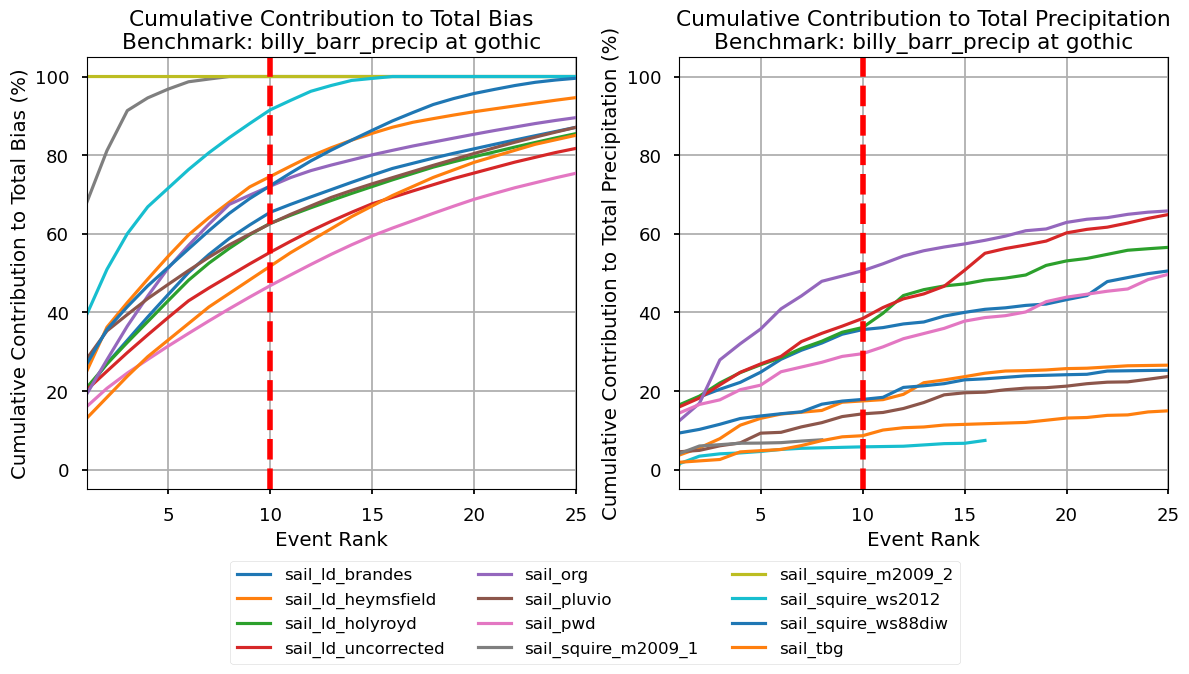

In [33]:
gothic_bias_df, gothic_total_ppt_df = compute_event_contributions(combinedGothicEvents_ds, benchmark_name='billy_barr_precip', bias='positive')

# for each, get the sum of the top 10 contributors
top_n = 10
bias_contribution_sums = gothic_bias_df.apply(lambda col: col.nlargest(top_n).sum())
total_ppt_contribution_sums = gothic_total_ppt_df.iloc[0:10].sum(axis=0)

plot_cumulative_contributions(gothic_bias_df, gothic_total_ppt_df, benchmark_name='billy_barr_precip', site='gothic', output_dir=OUTPUT_DIR, limit=25, top_n=top_n, save=False)

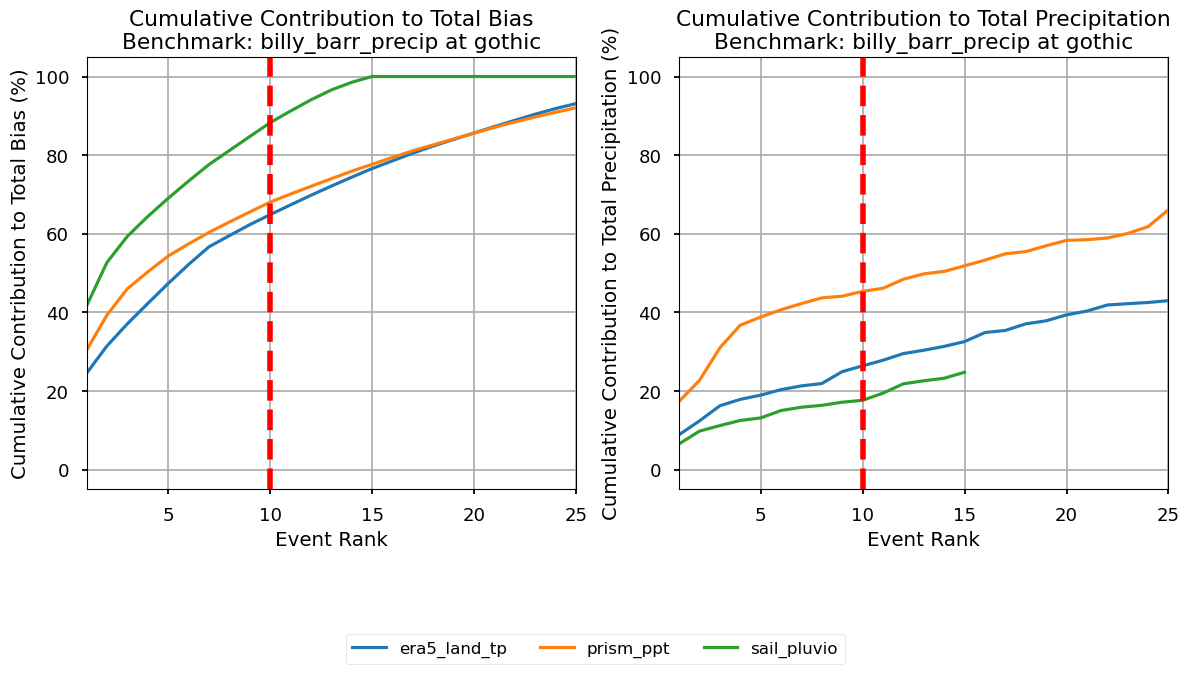

In [34]:
gothic_bias_df, gothic_total_ppt_df = compute_event_contributions(combinedGothicGriddedEvents_ds, benchmark_name='billy_barr_precip', bias='positive')

# for each, get the sum of the top 10 contributors
top_n = 10
bias_contribution_sums = gothic_bias_df.apply(lambda col: col.nlargest(top_n).sum())
total_ppt_contribution_sums = gothic_total_ppt_df.iloc[0:10].sum(axis=0)

plot_cumulative_contributions(gothic_bias_df, gothic_total_ppt_df, benchmark_name='billy_barr_precip', site='gothic', output_dir=OUTPUT_DIR, limit=25, top_n=top_n, save=False)

### Kettle Ponds

#### Negative bias contributions

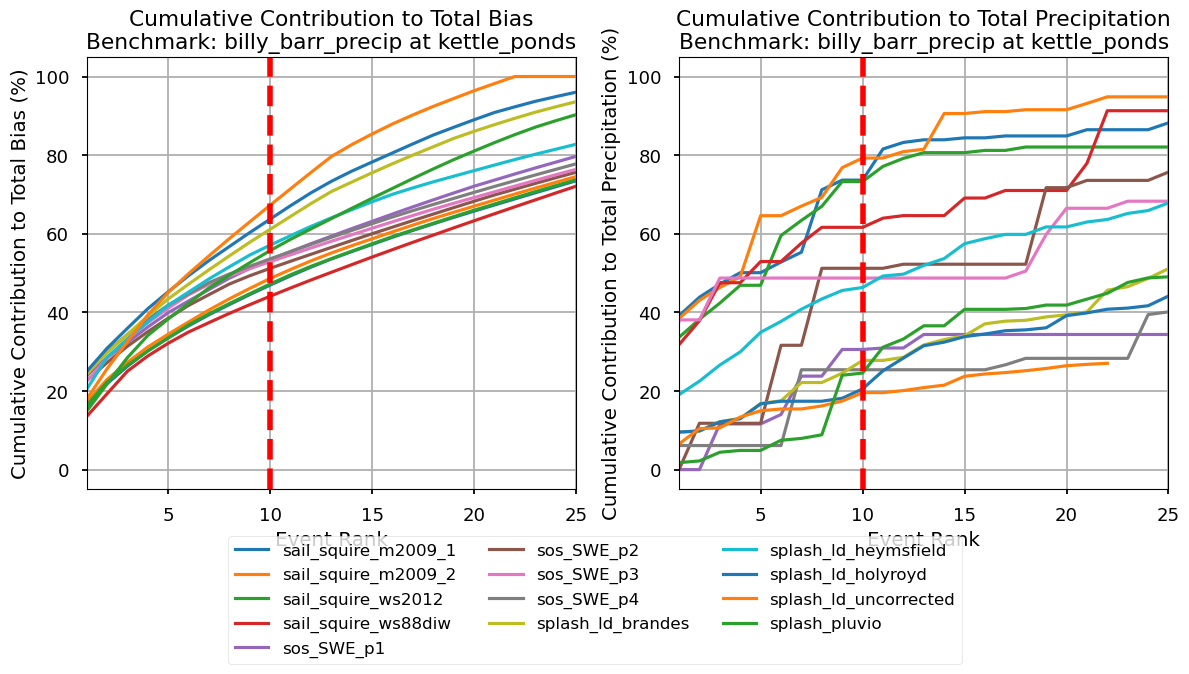

In [35]:
kettle_ponds_bias_df, kettle_ponds_total_ppt_df = compute_event_contributions(combinedKettlePondsEvents_ds, benchmark_name='billy_barr_precip', bias='negative')

# for each, get the sum of the top 10 contributors
top_n = 10
bias_contribution_sums = kettle_ponds_bias_df.apply(lambda col: col.nlargest(top_n).sum())
total_ppt_contribution_sums = kettle_ponds_total_ppt_df.iloc[0:10].sum(axis=0)

plot_cumulative_contributions(kettle_ponds_bias_df, kettle_ponds_total_ppt_df, benchmark_name='billy_barr_precip', site='kettle_ponds', output_dir=OUTPUT_DIR, limit=25, top_n=top_n, save=False)

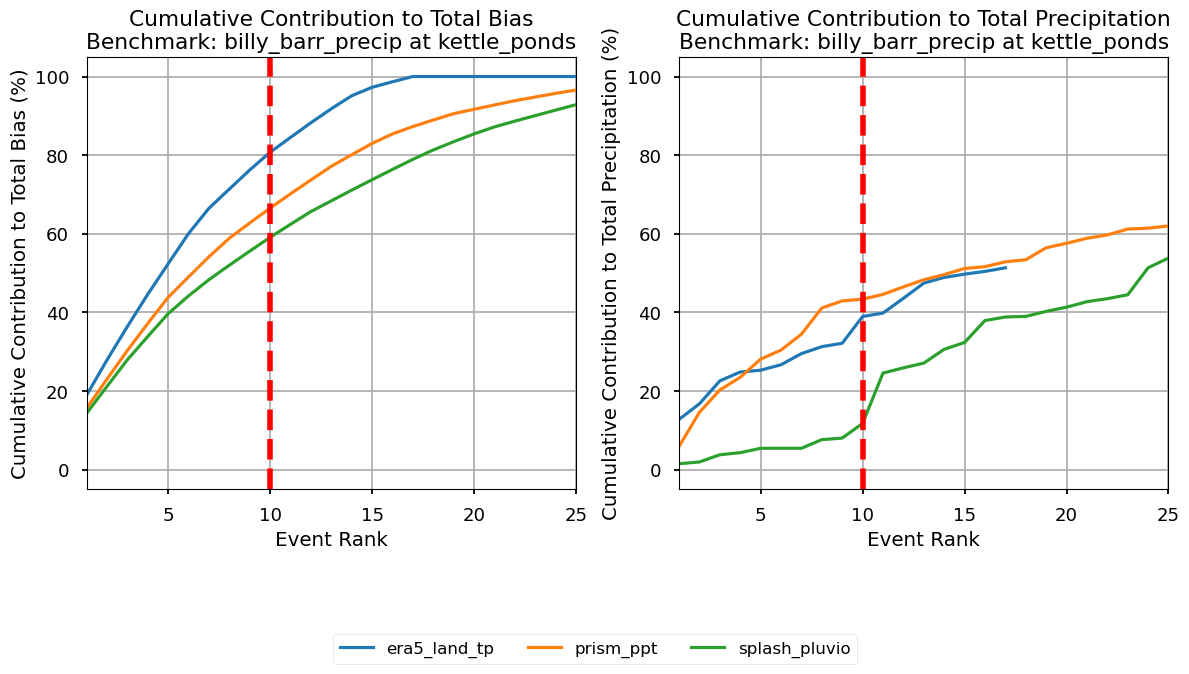

In [36]:
kettle_ponds_bias_df, kettle_ponds_total_ppt_df = compute_event_contributions(combinedKettlePondsGriddedEvents_ds, benchmark_name='billy_barr_precip', bias='negative')

# for each, get the sum of the top 10 contributors
top_n = 10
bias_contribution_sums = kettle_ponds_bias_df.apply(lambda col: col.nlargest(top_n).sum())
total_ppt_contribution_sums = kettle_ponds_total_ppt_df.iloc[0:10].sum(axis=0)

plot_cumulative_contributions(kettle_ponds_bias_df, kettle_ponds_total_ppt_df, benchmark_name='billy_barr_precip', site='kettle_ponds', output_dir=OUTPUT_DIR, limit=25, top_n=top_n, save=False)

#### Absolute bias contributions

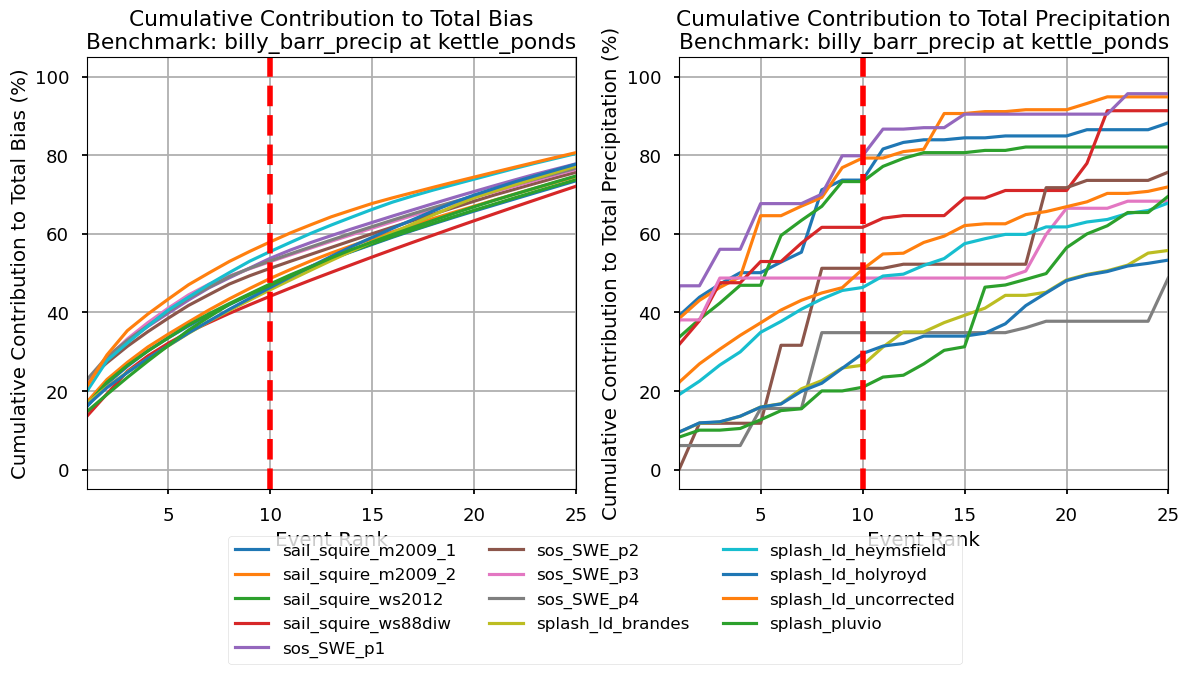

In [37]:
kettle_ponds_bias_df, kettle_ponds_total_ppt_df = compute_event_contributions(combinedKettlePondsEvents_ds, benchmark_name='billy_barr_precip', bias='absolute')

# for each, get the sum of the top 10 contributors
top_n = 10
bias_contribution_sums = kettle_ponds_bias_df.apply(lambda col: col.nlargest(top_n).sum())
total_ppt_contribution_sums = kettle_ponds_total_ppt_df.iloc[0:10].sum(axis=0)

plot_cumulative_contributions(kettle_ponds_bias_df, kettle_ponds_total_ppt_df, benchmark_name='billy_barr_precip', site='kettle_ponds', output_dir=OUTPUT_DIR, limit=25, top_n=top_n, save=False)

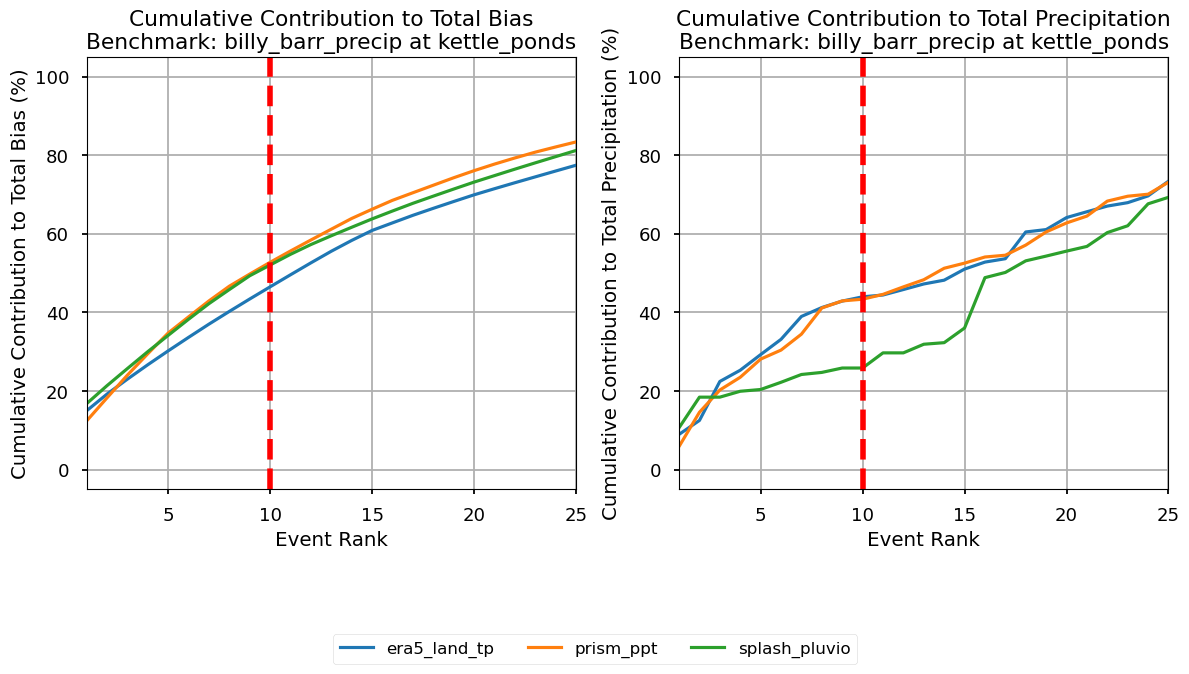

In [38]:
kettle_ponds_bias_df, kettle_ponds_total_ppt_df = compute_event_contributions(combinedKettlePondsGriddedEvents_ds, benchmark_name='billy_barr_precip', bias='absolute')

# for each, get the sum of the top 10 contributors
top_n = 10
bias_contribution_sums = kettle_ponds_bias_df.apply(lambda col: col.nlargest(top_n).sum())
total_ppt_contribution_sums = kettle_ponds_total_ppt_df.iloc[0:10].sum(axis=0)

plot_cumulative_contributions(kettle_ponds_bias_df, kettle_ponds_total_ppt_df, benchmark_name='billy_barr_precip', site='kettle_ponds', output_dir=OUTPUT_DIR, limit=25, top_n=top_n, save=False)

#### Positive bias contributions

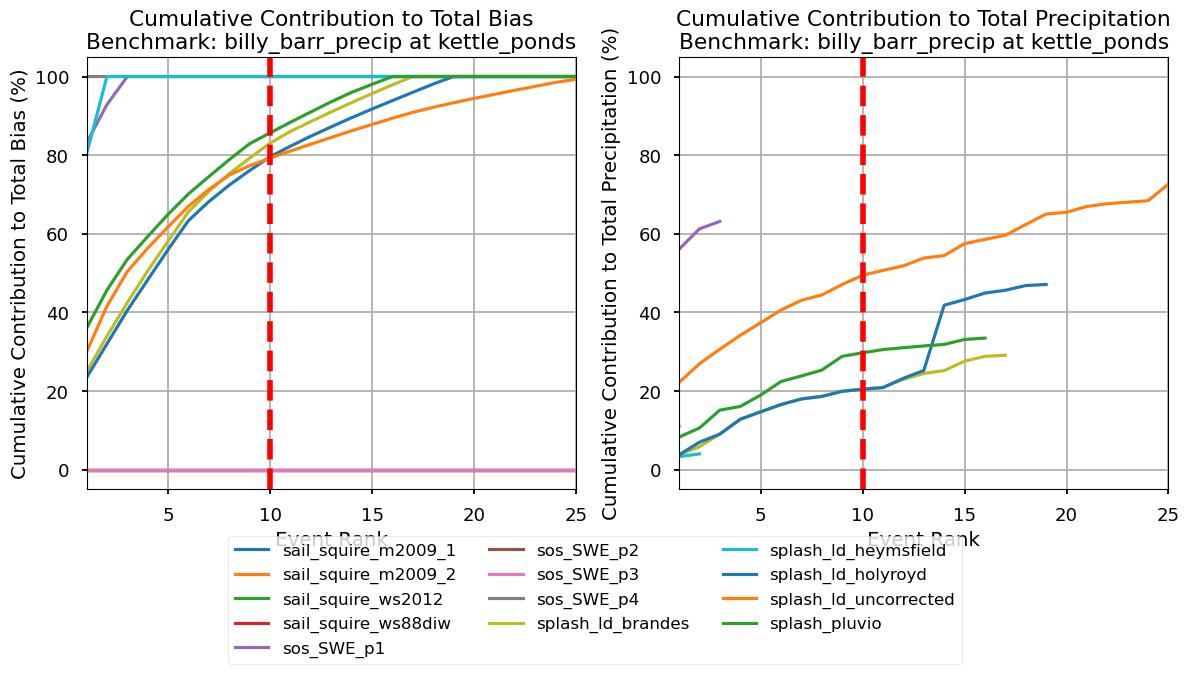

In [39]:
kettle_ponds_bias_df, kettle_ponds_total_ppt_df = compute_event_contributions(combinedKettlePondsEvents_ds, benchmark_name='billy_barr_precip', bias='positive')

# for each, get the sum of the top 10 contributors
top_n = 10
bias_contribution_sums = kettle_ponds_bias_df.apply(lambda col: col.nlargest(top_n).sum())
total_ppt_contribution_sums = kettle_ponds_total_ppt_df.iloc[0:10].sum(axis=0)

plot_cumulative_contributions(kettle_ponds_bias_df, kettle_ponds_total_ppt_df, benchmark_name='billy_barr_precip', site='kettle_ponds', output_dir=OUTPUT_DIR, limit=25, top_n=top_n, save=False)

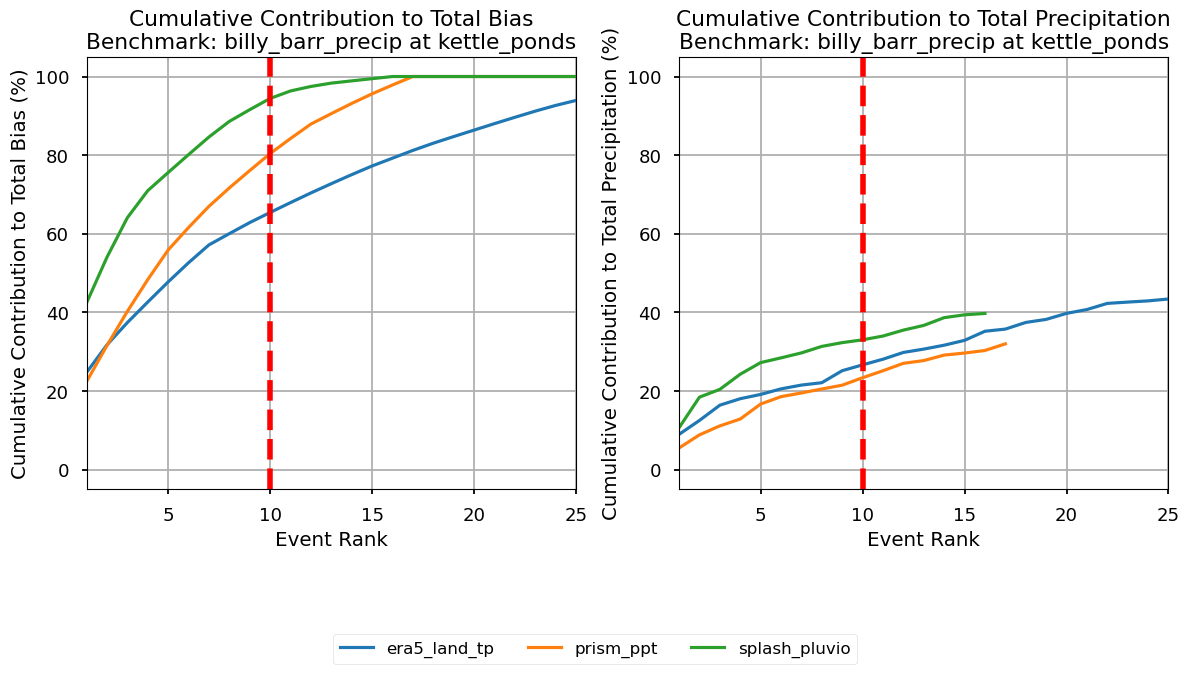

In [40]:
kettle_ponds_bias_df, kettle_ponds_total_ppt_df = compute_event_contributions(combinedKettlePondsGriddedEvents_ds, benchmark_name='billy_barr_precip', bias='positive')

# for each, get the sum of the top 10 contributors
top_n = 10
bias_contribution_sums = kettle_ponds_bias_df.apply(lambda col: col.nlargest(top_n).sum())
total_ppt_contribution_sums = kettle_ponds_total_ppt_df.iloc[0:10].sum(axis=0)

plot_cumulative_contributions(kettle_ponds_bias_df, kettle_ponds_total_ppt_df, benchmark_name='billy_barr_precip', site='kettle_ponds', output_dir=OUTPUT_DIR, limit=25, top_n=top_n, save=False)